<a href="https://colab.research.google.com/github/berrinaydogmus/softito-yapay-zeka/blob/main/MachineLearning2_21_09_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_curve, roc_auc_score)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
#Veri yükleme

sutunlar = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
            "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"]

heart = pd.read_csv("processed.cleveland.data", header=None, names=sutunlar, na_values="?")

print(heart.shape)
heart.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
#Eksik değerleri temizleme
print(heart.isna().sum())
heart = heart.dropna().reset_index(drop=True)
print(f"Temizlik sonrası satır sayısı: {len(heart)}")

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64
Temizlik sonrası satır sayısı: 297


In [4]:
#Hedef değişkeni ikili (binary) hale getirme
heart["hedef"] = (heart["num"] > 0).astype(int)

X_clf = heart.drop(columns=["num", "hedef"])
y_clf = heart["hedef"]

print("Sınıf dağılımı (0=yok, 1=var):")
print(y_clf.value_counts())

Sınıf dağılımı (0=yok, 1=var):
hedef
0    160
1    137
Name: count, dtype: int64


In [6]:
#Train/test ayrımı
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=SEED, stratify=y_clf
)
print(Xc_train.shape[0], Xc_test.shape[0])

237 60


In [7]:
#Sınıflandırıcıları karşılaştırma
siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent").fit(Xc_train, yc_train),
    "Logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(Xc_train, yc_train),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()).fit(Xc_train, yc_train),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED).fit(Xc_train, yc_train),
    "Rastgele orman": RandomForestClassifier(random_state=SEED).fit(Xc_train, yc_train),
}

In [8]:
satirlar = []
for ad, m in siniflandiricilar.items():
    satirlar.append({
        "Model": ad,
        "Eğitim": accuracy_score(yc_train, m.predict(Xc_train)),
        "Test": accuracy_score(yc_test, m.predict(Xc_test)),
    })

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.540,0.533
Logistic,0.852,0.833
KNN,0.869,0.883
Karar ağacı,1.000,0.700
Rastgele orman,1.000,0.850


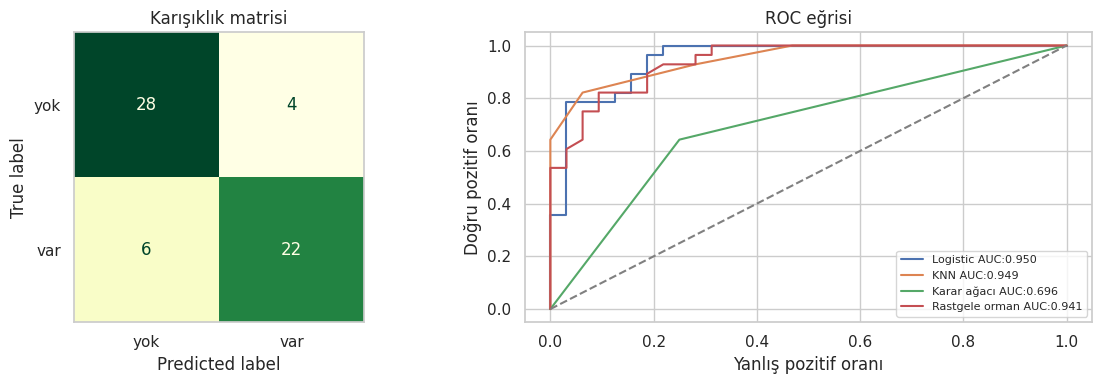

In [9]:
#Karışıklık matrisi ve ROC eğrisi
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model = siniflandiricilar["Logistic"]
tahmin = model.predict(Xc_test)

ConfusionMatrixDisplay.from_predictions(
    yc_test, tahmin, display_labels=["yok", "var"], cmap="YlGn", ax=axes[0], colorbar=False
)
axes[0].set_title("Karışıklık matrisi")
axes[0].grid(False)

for ad in ["Logistic", "KNN", "Karar ağacı", "Rastgele orman"]:
    p = siniflandiricilar[ad].predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, p)
    axes[1].plot(fpr, tpr, label=f"{ad} AUC:{roc_auc_score(yc_test, p):.3f}")

axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_xlabel("Yanlış pozitif oranı")
axes[1].set_ylabel("Doğru pozitif oranı")
axes[1].set_title("ROC eğrisi")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
#Çapraz doğrulama (cross-validation)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

satirlar = []
for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    satirlar.append({"Model": ad, "Ortalama skor": skorlar.mean(), "Standart sapma": skorlar.std()})

cv_sonuc = pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
cv_sonuc

,Ortalama skor,Standart sapma
Model,,
Logistic,0.827,0.059
Rastgele orman,0.789,0.079
KNN,0.776,0.076
Karar ağacı,0.721,0.071
Baseline,0.540,0.008


In [11]:
#GridSearchCV ile hiperparametre arama (KNN örneği)
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "kneighborsclassifier__weights": ["uniform", "distance"],
}

opt = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
opt.fit(Xc_train, yc_train)

print("En iyi parametreler:", opt.best_params_)
print(f"En iyi cv skoru: {opt.best_score_:.3f}")

En iyi parametreler: {'kneighborsclassifier__n_neighbors': 21, 'kneighborsclassifier__weights': 'uniform'}
En iyi cv skoru: 0.827


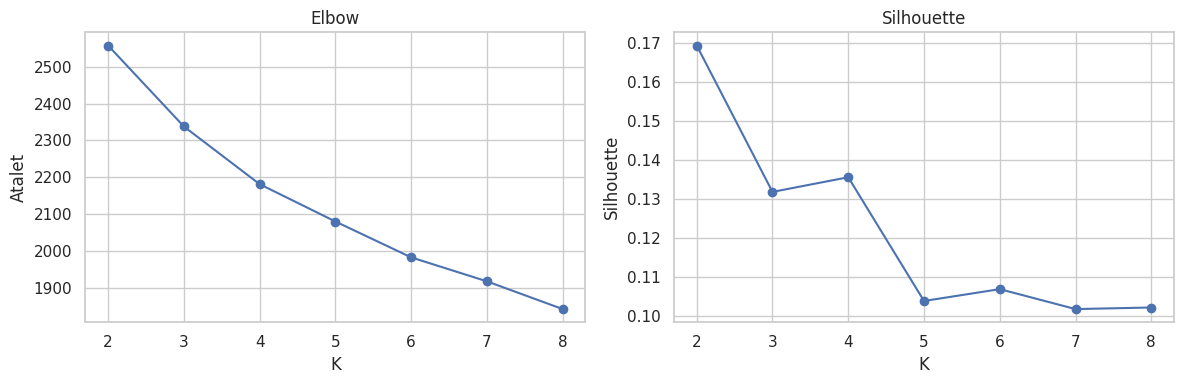

In [12]:
#K-Means kümeleme
scaler = StandardScaler().fit(Xc_train)
Xc_tr_scaled = scaler.transform(Xc_train)

k_degerleri = range(2, 9)
atalet, silhouette = [], []

for k in k_degerleri:
    km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xc_tr_scaled)
    atalet.append(km.inertia_)
    silhouette.append(silhouette_score(Xc_tr_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_degerleri, atalet, marker="o")
axes[0].set_title("Elbow")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Atalet")

axes[1].plot(k_degerleri, silhouette, marker="o")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()